<a href="https://colab.research.google.com/github/Shlok1524/Crowd-Anomaly-Detection/blob/main/epics.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Unsupervised CNN

In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
!pip install opencv-python numpy matplotlib torch torchvision tqdm


In [ ]:
import os
import cv2
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
from tqdm import tqdm


In [ ]:
BASE_PATH = "/content/drive/MyDrive/Dataset/Abnormal High-density Crowds"

TRAIN_PATH = os.path.join(
    BASE_PATH,
    "1_Times_Square",
    "View_1",
    "Train"   # normal frames only
)

TEST_PATH = os.path.join(
    BASE_PATH,
    "1_Times_Square",
    "View_1",
    "Test"    # abnormal frames
)

print("Train frames:", len(os.listdir(TRAIN_PATH)))
print("Test frames:", len(os.listdir(TEST_PATH)))


Train frames: 379
Test frames: 1026


In [ ]:
class CrowdFrameDataset(Dataset):
    def __init__(self, folder, resize=(256, 256)):
        self.folder = folder
        self.files = sorted([
            f for f in os.listdir(folder)
            if f.lower().endswith(".png")
        ])
        self.resize = resize

    def __len__(self):
        return len(self.files)

    def __getitem__(self, idx):
        img_path = os.path.join(self.folder, self.files[idx])
        img = cv2.imread(img_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img = cv2.resize(img, self.resize)
        img = img / 255.0
        img = torch.tensor(img, dtype=torch.float32).permute(2, 0, 1)
        return img


In [ ]:
train_dataset = CrowdFrameDataset(TRAIN_PATH)
train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True)

sample = next(iter(train_loader))
print("Sample batch shape:", sample.shape)


Sample batch shape: torch.Size([8, 3, 256, 256])



MODEL 1: CNN AUTOENCODER (APPEARANCE-BASED ANOMALY DETECTION)

Learns normal crowd appearance using reconstruction error

Output: smooth_scores


In [ ]:
class CrowdAutoencoder(nn.Module):
    def __init__(self):
        super().__init__()

        self.encoder = nn.Sequential(
            nn.Conv2d(3, 16, 3, stride=2, padding=1),
            nn.ReLU(),
            nn.Conv2d(16, 32, 3, stride=2, padding=1),
            nn.ReLU(),
            nn.Conv2d(32, 64, 3, stride=2, padding=1),
            nn.ReLU()
        )

        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(64, 32, 4, stride=2, padding=1),
            nn.ReLU(),
            nn.ConvTranspose2d(32, 16, 4, stride=2, padding=1),
            nn.ReLU(),
            nn.ConvTranspose2d(16, 3, 4, stride=2, padding=1),
            nn.Sigmoid()
        )

    def forward(self, x):
        z = self.encoder(x)
        out = self.decoder(z)
        return out


In [ ]:
device = "cuda" if torch.cuda.is_available() else "cpu"

model = CrowdAutoencoder().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
criterion = nn.MSELoss()

EPOCHS = 10

for epoch in range(EPOCHS):
    model.train()
    total_loss = 0

    for batch in tqdm(train_loader):
        batch = batch.to(device)

        optimizer.zero_grad()
        recon = model(batch)
        loss = criterion(recon, batch)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    print(f"Epoch {epoch+1}/{EPOCHS} | Loss: {total_loss/len(train_loader):.6f}")


100%|██████████| 48/48 [00:17<00:00,  2.79it/s]


Epoch 1/10 | Loss: 0.041313


100%|██████████| 48/48 [00:16<00:00,  2.94it/s]


Epoch 2/10 | Loss: 0.019038


100%|██████████| 48/48 [00:14<00:00,  3.22it/s]


...

Epoch 8/10 | Loss: 0.013105


100%|██████████| 48/48 [00:14<00:00,  3.23it/s]


Epoch 9/10 | Loss: 0.012697


100%|██████████| 48/48 [00:14<00:00,  3.26it/s]

Epoch 10/10 | Loss: 0.012396


In [ ]:
test_dataset = CrowdFrameDataset(TEST_PATH)
test_loader = DataLoader(test_dataset, batch_size=1, shuffle=False)

model.eval()
anomaly_scores = []

with torch.no_grad():
    for frame in tqdm(test_loader):
        frame = frame.to(device)
        recon = model(frame)
        error = torch.mean((frame - recon) ** 2).item()
        anomaly_scores.append(error)

print("Anomaly score sample:", anomaly_scores[:10])


100%|██████████| 1026/1026 [01:26<00:00, 11.85it/s]

Anomaly score sample: [0.012720858678221703, 0.012858666479587555, 0.012904835864901543, 0.01290629617869854, 0.01251060888171196, 0.012359621934592724, 0.01225910522043705, 0.012254618108272552, 0.012253554537892342, 0.012206124141812325]


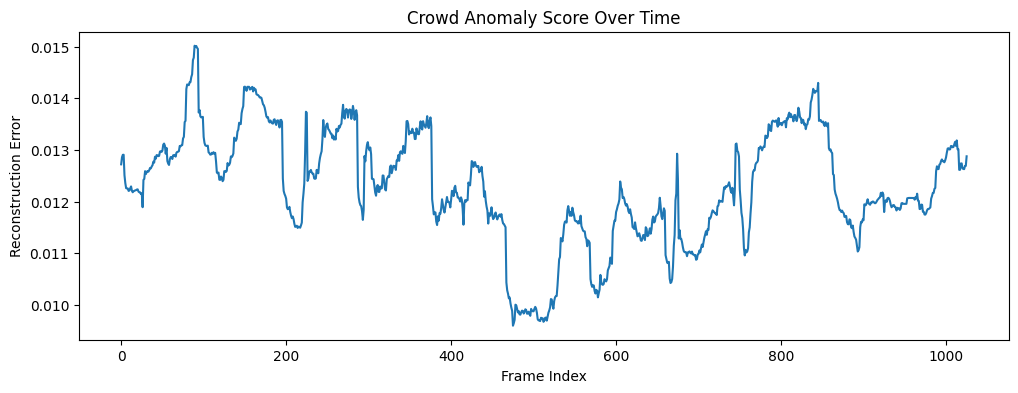

In [ ]:
plt.figure(figsize=(12,4))
plt.plot(anomaly_scores)
plt.title("Crowd Anomaly Score Over Time")
plt.xlabel("Frame Index")
plt.ylabel("Reconstruction Error")
plt.show()


In [ ]:
scores = np.array(anomaly_scores)
mean = scores.mean()
std = scores.std()

z_scores = (scores - mean) / std


In [ ]:
from scipy.ndimage import gaussian_filter1d

smooth_scores = gaussian_filter1d(z_scores, sigma=10)


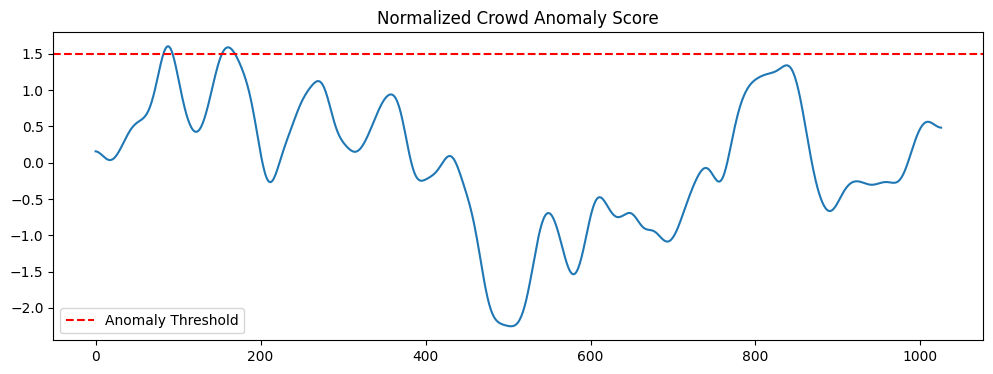

In [ ]:
plt.figure(figsize=(12,4))
plt.plot(smooth_scores)
plt.axhline(1.5, color='r', linestyle='--', label='Anomaly Threshold')
plt.legend()
plt.title("Normalized Crowd Anomaly Score")
plt.show()



MODEL 2: OPTICAL FLOW (MOTION-BASED ANOMALY DETECTION)

Computes motion magnitude between frames

Output: flow_smooth


In [ ]:
flow_magnitudes = []

prev_gray = None

for i in range(len(test_dataset)):
    img = test_dataset[i]
    img_np = (img.permute(1,2,0).numpy() * 255).astype(np.uint8)
    gray = cv2.cvtColor(img_np, cv2.COLOR_RGB2GRAY)

    if prev_gray is None:
        prev_gray = gray
        flow_magnitudes.append(0)
        continue

    flow = cv2.calcOpticalFlowFarneback(
        prev_gray, gray,
        None, 0.5, 3, 15, 3, 5, 1.2, 0
    )

    mag, _ = cv2.cartToPolar(flow[...,0], flow[...,1])
    flow_magnitudes.append(np.mean(mag))

    prev_gray = gray


In [ ]:
flow_magnitudes = np.array(flow_magnitudes)

flow_z = (flow_magnitudes - flow_magnitudes.mean()) / flow_magnitudes.std()
flow_smooth = gaussian_filter1d(flow_z, sigma=10)


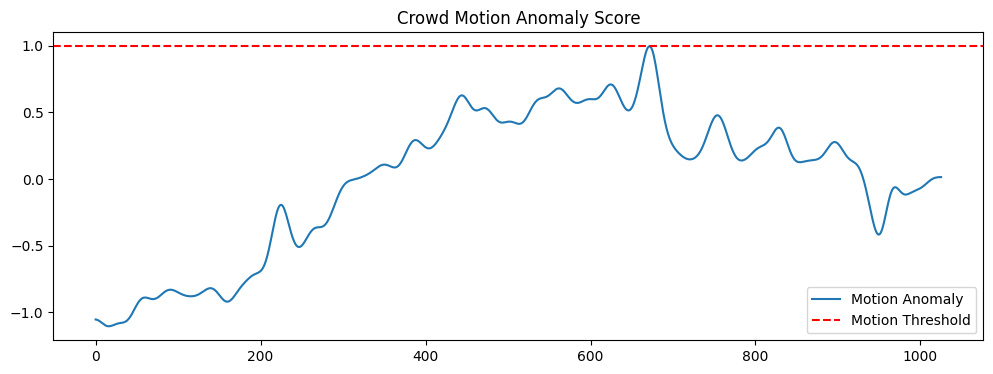

In [ ]:
plt.figure(figsize=(12,4))
plt.plot(flow_smooth, label="Motion Anomaly")
plt.axhline(1.0, color='r', linestyle='--', label='Motion Threshold')
plt.legend()
plt.title("Crowd Motion Anomaly Score")
plt.show()


In [ ]:
adaptive_threshold = np.percentile(flow_smooth, 95)
print("Adaptive threshold:", adaptive_threshold)


Adaptive threshold: 0.6655927180013087


In [ ]:
window = 30  # ~1 second if ~30 FPS
motion_anomaly_segments = []

for i in range(len(flow_smooth) - window):
    if np.mean(flow_smooth[i:i+window]) > adaptive_threshold:
        motion_anomaly_segments.append(i)

print("Detected anomaly segments (sample):", motion_anomaly_segments[:10])


Detected anomaly segments (sample): [640, 641, 642, 643, 644, 645, 646, 647, 648, 649]


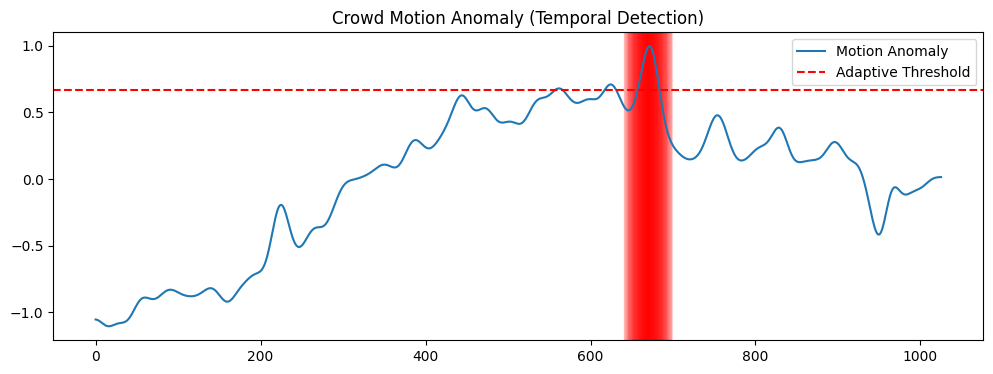

In [ ]:
plt.figure(figsize=(12,4))
plt.plot(flow_smooth, label="Motion Anomaly")
plt.axhline(adaptive_threshold, color='r', linestyle='--', label='Adaptive Threshold')

for idx in motion_anomaly_segments:
    plt.axvspan(idx, idx+window, color='red', alpha=0.1)

plt.legend()
plt.title("Crowd Motion Anomaly (Temporal Detection)")
plt.show()



MODEL 3: AE + OPTICAL FLOW (HYBRID FUSION MODEL)

Combines appearance and motion signals

Output: final_score


In [ ]:
# Normalize both scores to comparable scale
app = (smooth_scores - np.mean(smooth_scores)) / np.std(smooth_scores)
mot = (flow_smooth - np.mean(flow_smooth)) / np.std(flow_smooth)

# Weighted fusion (motion more important in crowds)
final_score = 0.4 * app + 0.6 * mot

# Smooth again
final_score = gaussian_filter1d(final_score, sigma=10)


Detected anomaly segments (sample): [782, 783, 784, 785, 786, 787, 788, 789, 790, 791, 792, 793, 794, 795, 796, 797, 798, 799, 800, 801, 802, 803, 804, 805, 806, 807, 808, 809, 810, 811, 812, 813, 814, 815, 816, 817, 818, 819, 820, 821, 822, 823, 824, 825, 826, 827, 828, 829, 830, 831]


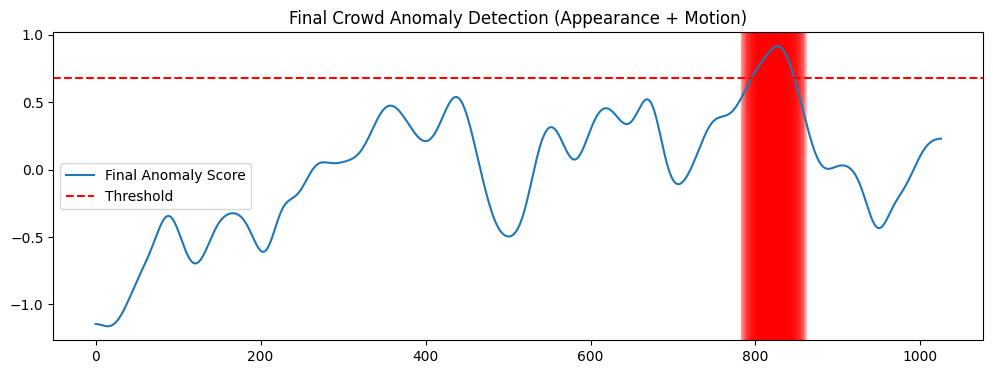

In [ ]:
final_threshold = np.percentile(final_score, 95)
window = 30

final_segments = []
for i in range(len(final_score) - window):
    if np.mean(final_score[i:i+window]) > final_threshold:
        final_segments.append(i)

print("Detected anomaly segments (sample):", final_segments)

plt.figure(figsize=(12,4))
plt.plot(final_score, label="Final Anomaly Score")
plt.axhline(final_threshold, color='r', linestyle='--', label="Threshold")

for idx in final_segments:
    plt.axvspan(idx, idx+window, color='red', alpha=0.15)

plt.legend()
plt.title("Final Crowd Anomaly Detection (Appearance + Motion)")
plt.show()


Determine the Ground Truth Window by looking at the Final Crowd Anomaly Detection Graph

In [ ]:
# ====== Ground Truth (EDIT THIS) ======
# Example: anomaly starts at frame ~650 and ends at ~750
GT_START = 780
GT_END = 830

print("Ground truth anomaly window:", GT_START, "to", GT_END)


Ground truth anomaly window: 780 to 830


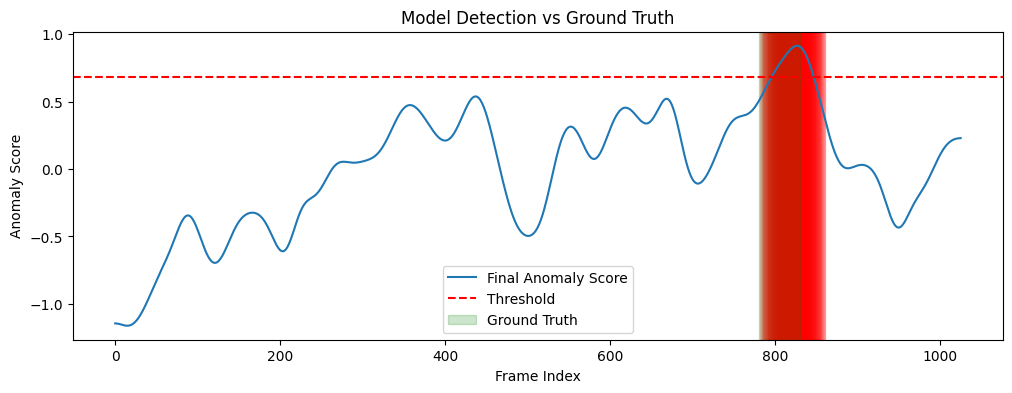

In [ ]:
plt.figure(figsize=(12,4))

# Plot final anomaly score
plt.plot(final_score, label="Final Anomaly Score")

# Threshold
plt.axhline(final_threshold, color='r', linestyle='--', label="Threshold")

# Detected anomaly regions
for idx in final_segments:
    plt.axvspan(idx, idx+window, color='red', alpha=0.15)

# Ground truth region
plt.axvspan(GT_START, GT_END, color='green', alpha=0.2, label="Ground Truth")

plt.legend()
plt.title("Model Detection vs Ground Truth")
plt.xlabel("Frame Index")
plt.ylabel("Anomaly Score")
plt.show()


In [ ]:
# Total number of frames
N = len(final_score)

# Initialize labels
y_pred = np.zeros(N)
y_true = np.zeros(N)

# Mark predicted anomaly frames
for idx in final_segments:
    y_pred[idx:idx+window] = 1

# Mark ground truth frames
y_true[GT_START:GT_END] = 1

TP = np.sum((y_pred == 1) & (y_true == 1))  # True Positives
FP = np.sum((y_pred == 1) & (y_true == 0))  # False Positives
FN = np.sum((y_pred == 0) & (y_true == 1))  # False Negatives
TN = np.sum((y_pred == 0) & (y_true == 0))  # True Negatives

precision = TP / (TP + FP + 1e-8)
recall = TP / (TP + FN + 1e-8)
f1_score = 2 * (precision * recall) / (precision + recall + 1e-8)

print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1 Score: {f1_score:.4f}")

Precision: 0.6076
Recall: 0.9600
F1 Score: 0.7442


In [ ]:
intersection = np.sum((y_pred == 1) & (y_true == 1))
union = np.sum((y_pred == 1) | (y_true == 1))

iou = intersection / (union + 1e-8)
print(f"IoU: {iou:.4f}")

IoU: 0.5926


In [ ]:
def temporal_iou(pred_segments, gt_start, gt_end, window):
    ious = []
    for idx in pred_segments:
        pred_start = idx
        pred_end = idx + window

        inter = max(0, min(pred_end, gt_end) - max(pred_start, gt_start))
        union = max(pred_end, gt_end) - min(pred_start, gt_start)

        ious.append(inter / union)

    return max(ious) if ious else 0


tiou = temporal_iou(final_segments, GT_START, GT_END, window)
print("Temporal IoU:", round(tiou, 3))


Temporal IoU: 0.6


In [ ]:
# Find the first detection AFTER ground truth start
valid_detections = [
    idx for idx in final_segments
    if idx >= GT_START
]

if len(valid_detections) > 0:
    detected_start = valid_detections[0]
    delay = detected_start - GT_START

    print("Detected anomaly start:", detected_start)
    print("Ground truth start:", GT_START)
    print("Detection delay (frames):", delay)
else:
    print("No detection after ground truth")


Detected anomaly start: 782
Ground truth start: 780
Detection delay (frames): 2


In [ ]:
frames_to_explain = {
    "Normal": GT_START - 150,
    "Pre-onset": GT_START - 50,
    "Onset": GT_START,
    "Peak": max(final_segments) + window//2
}

frames_to_explain


{'Normal': 630, 'Pre-onset': 730, 'Onset': 780, 'Peak': 846}

In [ ]:
def motion_magnitude(frame_idx):
    img1 = test_dataset[frame_idx - 1].permute(1,2,0).numpy()
    img2 = test_dataset[frame_idx].permute(1,2,0).numpy()

    g1 = cv2.cvtColor((img1*255).astype(np.uint8), cv2.COLOR_RGB2GRAY)
    g2 = cv2.cvtColor((img2*255).astype(np.uint8), cv2.COLOR_RGB2GRAY)

    flow = cv2.calcOpticalFlowFarneback(
        g1, g2, None, 0.5, 3, 15, 3, 5, 1.2, 0
    )
    mag, _ = cv2.cartToPolar(flow[...,0], flow[...,1])
    return mag

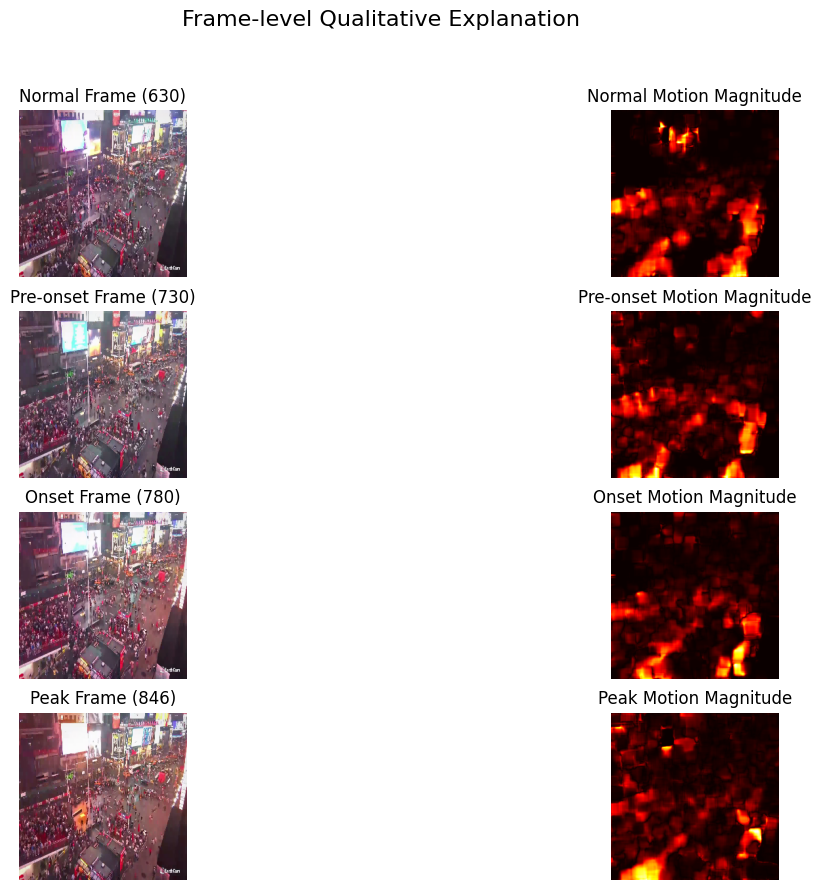

In [ ]:
plt.figure(figsize=(14,10))

i = 1
for label, idx in frames_to_explain.items():
    # Raw frame
    plt.subplot(4, 2, i)
    plt.imshow(test_dataset[idx].permute(1,2,0).numpy())
    plt.title(f"{label} Frame ({idx})")
    plt.axis("off")

    # Motion magnitude
    plt.subplot(4, 2, i+1)
    mag = motion_magnitude(idx)
    plt.imshow(mag, cmap="hot")
    plt.title(f"{label} Motion Magnitude")
    plt.axis("off")

    i += 2

plt.suptitle("Frame-level Qualitative Explanation", fontsize=16)
plt.show()


MODEL 4: CONVLSTM AUTOENCODER (TEMPORAL DEEP MODEL)

Learns spatio-temporal crowd behavior from sequences

Output: lstm_smooth


In [ ]:
class CrowdSequenceDataset(Dataset):
    def __init__(self, folder, seq_len=10, resize=(256,256)):
        self.folder = folder
        self.files = sorted([f for f in os.listdir(folder) if f.endswith(".png")])
        self.seq_len = seq_len
        self.resize = resize

    def __len__(self):
        return len(self.files) - self.seq_len

    def __getitem__(self, idx):
        seq = []
        for i in range(idx, idx + self.seq_len):
            img = cv2.imread(os.path.join(self.folder, self.files[i]))
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            img = cv2.resize(img, self.resize)
            img = img / 255.0
            img = torch.tensor(img, dtype=torch.float32).permute(2,0,1)
            seq.append(img)
        return torch.stack(seq)  # [T, C, H, W]

In [ ]:
SEQ_LEN = 10

train_seq_dataset = CrowdSequenceDataset(TRAIN_PATH, seq_len=SEQ_LEN)
train_seq_loader = DataLoader(train_seq_dataset, batch_size=2, shuffle=True)

sample_seq = next(iter(train_seq_loader))
print("Sequence shape:", sample_seq.shape)

Sequence shape: torch.Size([2, 10, 3, 256, 256])


In [ ]:
class ConvLSTMCell(nn.Module):
    def __init__(self, input_dim, hidden_dim, kernel_size):
        super().__init__()
        padding = kernel_size // 2
        self.conv = nn.Conv2d(
            input_dim + hidden_dim,
            4 * hidden_dim,
            kernel_size,
            padding=padding
        )
        self.hidden_dim = hidden_dim

    def forward(self, x, h_prev, c_prev):
        combined = torch.cat([x, h_prev], dim=1)
        conv_out = self.conv(combined)

        cc_i, cc_f, cc_o, cc_g = torch.split(
            conv_out, self.hidden_dim, dim=1
        )

        i = torch.sigmoid(cc_i)
        f = torch.sigmoid(cc_f)
        o = torch.sigmoid(cc_o)
        g = torch.tanh(cc_g)

        c = f * c_prev + i * g
        h = o * torch.tanh(c)
        return h, c

In [ ]:
class ConvLSTMAutoencoderV2(nn.Module):
    def __init__(self):
        super().__init__()

        # Encoder
        self.enc = nn.Sequential(
            nn.Conv2d(3, 32, 3, stride=2, padding=1),
            nn.ReLU(),
            nn.Conv2d(32, 64, 3, stride=2, padding=1),
            nn.ReLU()
        )

        # ConvLSTM
        self.convlstm = ConvLSTMCell(
            input_dim=64,
            hidden_dim=64,
            kernel_size=3
        )

        # Decoder
        self.dec = nn.Sequential(
            nn.ConvTranspose2d(64, 32, 4, stride=2, padding=1),
            nn.ReLU(),
            nn.ConvTranspose2d(32, 3, 4, stride=2, padding=1),
            nn.Sigmoid()
        )

    def forward(self, x_seq):
        B, T, C, H, W = x_seq.shape

        h = torch.zeros(B, 64, H//4, W//4).to(x_seq.device)
        c = torch.zeros_like(h)

        outputs = []

        for t in range(T):
            feat = self.enc(x_seq[:, t])
            h, c = self.convlstm(feat, h, c)

            # Decode at every timestep
            out = self.dec(h)
            outputs.append(out)

        return torch.stack(outputs, dim=1)  # [B, T, C, H, W]

In [ ]:
model_lstm = ConvLSTMAutoencoderV2().to(device)
optimizer = torch.optim.Adam(model_lstm.parameters(), lr=1e-4)
criterion = nn.MSELoss()

EPOCHS = 8

for epoch in range(EPOCHS):
    model_lstm.train()
    total_loss = 0

    for seq in train_seq_loader:
        seq = seq.to(device)

        optimizer.zero_grad()
        recon = model_lstm(seq)

        loss = criterion(recon, seq)  # full sequence loss
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    print(f"Epoch {epoch+1}/{EPOCHS} | Loss: {total_loss/len(train_seq_loader):.6f}")

Epoch 1/8 | Loss: 0.032975
Epoch 2/8 | Loss: 0.016080
Epoch 3/8 | Loss: 0.013767
Epoch 4/8 | Loss: 0.012158
Epoch 5/8 | Loss: 0.011132
Epoch 6/8 | Loss: 0.010397
Epoch 7/8 | Loss: 0.009779
Epoch 8/8 | Loss: 0.009195


In [ ]:
test_seq_dataset = CrowdSequenceDataset(TEST_PATH, seq_len=SEQ_LEN)
test_seq_loader = DataLoader(test_seq_dataset, batch_size=1, shuffle=False)

model_lstm.eval()
lstm_scores = []

with torch.no_grad():
    for seq in test_seq_loader:
        seq = seq.to(device)
        recon = model_lstm(seq)
        error = torch.mean((seq - recon) ** 2).item()
        lstm_scores.append(error)

lstm_scores = np.array(lstm_scores)

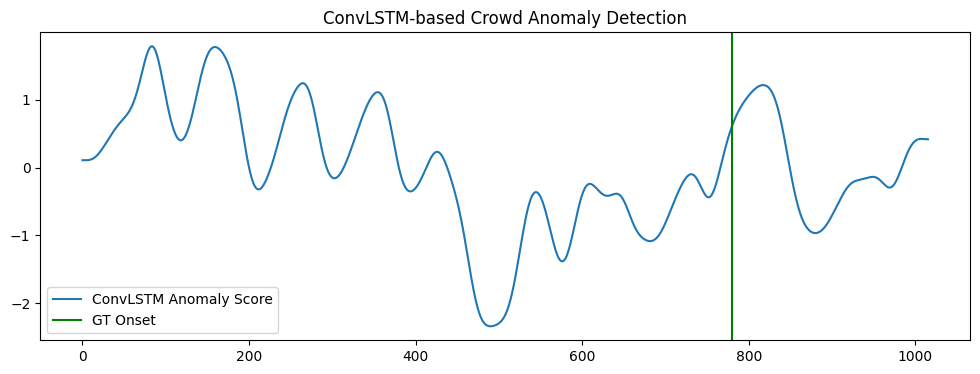

In [ ]:
lstm_z = (lstm_scores - lstm_scores.mean()) / lstm_scores.std()
lstm_smooth = gaussian_filter1d(lstm_z, sigma=10)

plt.figure(figsize=(12,4))
plt.plot(lstm_smooth, label="ConvLSTM Anomaly Score")
plt.axvline(GT_START, color='green', label="GT Onset")
plt.legend()
plt.title("ConvLSTM-based Crowd Anomaly Detection")
plt.show()

Comparison AE, Fusion, AE+Flow, ConvLSTM

In [ ]:
# ===== STEP 4A: Align all model scores =====

# Sequence offset due to ConvLSTM
offset = SEQ_LEN = 10

# Align all scores
aligned_ae = smooth_scores[offset:]
aligned_flow = flow_smooth[offset:]
aligned_fusion = final_score[offset:]
aligned_lstm = lstm_smooth

# Make all same length
min_len = min(
    len(aligned_ae),
    len(aligned_flow),
    len(aligned_fusion),
    len(aligned_lstm)
)

aligned_ae = aligned_ae[:min_len]
aligned_flow = aligned_flow[:min_len]
aligned_fusion = aligned_fusion[:min_len]
aligned_lstm = aligned_lstm[:min_len]

# Adjust ground truth index for alignment
aligned_GT = GT_START - offset

print("Aligned length:", min_len)
print("Adjusted GT index:", aligned_GT)

Aligned length: 1016
Adjusted GT index: 770


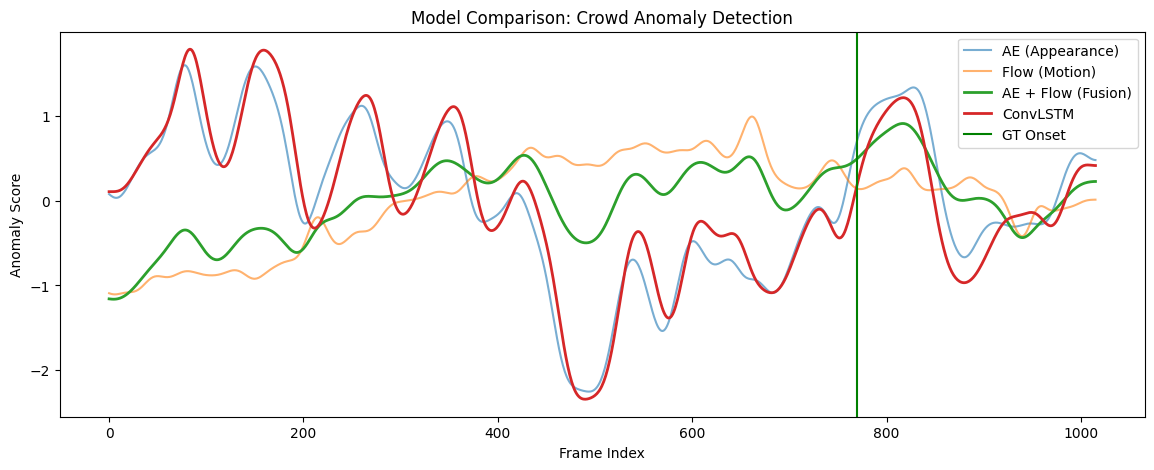

In [ ]:
plt.figure(figsize=(14,5))

plt.plot(aligned_ae, label="AE (Appearance)", alpha=0.6)
plt.plot(aligned_flow, label="Flow (Motion)", alpha=0.6)
plt.plot(aligned_fusion, label="AE + Flow (Fusion)", linewidth=2)
plt.plot(aligned_lstm, label="ConvLSTM", linewidth=2)

plt.axvline(aligned_GT, color='green', label="GT Onset")

plt.legend()
plt.title("Model Comparison: Crowd Anomaly Detection")
plt.xlabel("Frame Index")
plt.ylabel("Anomaly Score")
plt.show()

In [ ]:
def compute_delay(score, threshold_percentile=95):
    threshold = np.percentile(score, threshold_percentile)

    for i in range(len(score)):
        if score[i] > threshold and i >= GT_START - offset:
            return i - (GT_START - offset)
    return None

print("AE delay:", compute_delay(aligned_ae))
print("Flow delay:", compute_delay(aligned_flow))
print("Fusion delay:", compute_delay(aligned_fusion))
print("ConvLSTM delay:", compute_delay(aligned_lstm))

AE delay: 56
Flow delay: None
Fusion delay: 16
ConvLSTM delay: None


In [ ]:
def peak_strength(score):
    return np.max(score) - np.mean(score)

print("AE peak:", peak_strength(aligned_ae))
print("Flow peak:", peak_strength(aligned_flow))
print("Fusion peak:", peak_strength(aligned_fusion))
print("ConvLSTM peak:", peak_strength(aligned_lstm))

AE peak: 1.6047744183748354
Flow peak: 0.9857002957730004
Fusion peak: 0.9034108422332221
ConvLSTM peak: 1.7925451049528958
